''' TO CLEAN THE DATA'''

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#configuration for plot grids
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset
df = pd.read_csv('../data/raw/ds_salaries.csv')

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print("\nColumn names:")
print(df.columns.tolist())


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\caryl\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\caryl\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\caryl\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\caryl\AppD

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

In [ ]:
df.head() #to show firist 5 rows

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [ ]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicates: {df.duplicated().sum()}")

Missing values:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Duplicates: 1171


In [ ]:
print(df.describe())

         work_year        salary  salary_in_usd  remote_ratio
count  3755.000000  3.755000e+03    3755.000000   3755.000000
mean   2022.373635  1.906956e+05  137570.389880     46.271638
std       0.691448  6.716765e+05   63055.625278     48.589050
min    2020.000000  6.000000e+03    5132.000000      0.000000
25%    2022.000000  1.000000e+05   95000.000000      0.000000
50%    2022.000000  1.380000e+05  135000.000000      0.000000
75%    2023.000000  1.800000e+05  175000.000000    100.000000
max    2023.000000  3.040000e+07  450000.000000    100.000000


In [ ]:
df = df.drop_duplicates()
print(f"Rows after removing duplicates: {len(df):,}")



# Step 2 — Check salary outliers
print(f"\nSalary in USD stats:")
print(f"Min:    ${df['salary_in_usd'].min():,.0f}")
print(f"Max:    ${df['salary_in_usd'].max():,.0f}")
print(f"Mean:   ${df['salary_in_usd'].mean():,.0f}")
print(f"Median: ${df['salary_in_usd'].median():,.0f}")

# Step 3 — Tingnan ang sobrang mataas na salary
print(f"\nJobs with salary > $300,000:")
print(df[df['salary_in_usd'] > 300000][['job_title', 
                                         'experience_level',
                                         'company_location',
                                         'salary_in_usd']])

Rows after removing duplicates: 2,584

Salary in USD stats:
Min:    $5,132
Max:    $450,000
Mean:   $133,409
Median: $130,000

Jobs with salary > $300,000:
                               job_title experience_level company_location  \
33              Computer Vision Engineer               SE               US   
68                     Applied Scientist               SE               US   
133            Machine Learning Engineer               SE               US   
145            Machine Learning Engineer               SE               US   
228                         Head of Data               EX               US   
358            Machine Learning Engineer               SE               US   
478             Director of Data Science               EX               US   
488                       Data Scientist               SE               US   
528                         AI Scientist               SE               IL   
649                       Data Architect               SE       

In [ ]:
# Tingnan natin yung sobrang baba
print(df[df['salary_in_usd'] < 20000][['job_title',
                                        'experience_level', 
                                        'employment_type',
                                        'company_location',
                                        'salary_in_usd']])


                          job_title experience_level employment_type  \
183              Staff Data Analyst               EX              FT   
217                   Data Engineer               EN              FT   
573   Autonomous Vehicle Technician               EN              FT   
735                  Data Scientist               MI              FT   
738               Lead Data Analyst               MI              FT   
...                             ...              ...             ...   
3720              Big Data Engineer               MI              FT   
3723       Computer Vision Engineer               SE              FT   
3729                   AI Scientist               EN              FT   
3734              Lead Data Analyst               MI              FT   
3735                   AI Scientist               EN              PT   

     company_location  salary_in_usd  
183                CA          15000  
217                IN          17022  
573               

In [ ]:
# Filter out extremely low salaries
# Most likely non-representative ng 
# typical DS job market

before = len(df)
df = df[df['salary_in_usd'] >= 15000]
after = len(df)

print(f"Removed: {before - after} rows")
print(f"Remaining: {after:,} rows")
print(f"\nNew salary stats:")
print(f"Min:    ${df['salary_in_usd'].min():,.0f}")
print(f"Max:    ${df['salary_in_usd'].max():,.0f}")
print(f"Mean:   ${df['salary_in_usd'].mean():,.0f}")
print(f"Median: ${df['salary_in_usd'].median():,.0f}")

Removed: 46 rows
Remaining: 2,538 rows

New salary stats:
Min:    $15,000
Max:    $450,000
Mean:   $135,653
Median: $130,000


In [ ]:
cat_cols = ['experience_level', 'employment_type', 
            'company_size', 'remote_ratio']

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


experience_level:
experience_level
SE    1551
MI     649
EN     242
EX      96
Name: count, dtype: int64

employment_type:
employment_type
FT    2508
PT      12
CT       9
FL       9
Name: count, dtype: int64

company_size:
company_size
M    2015
L     391
S     132
Name: count, dtype: int64

remote_ratio:
remote_ratio
100    1187
0      1176
50      175
Name: count, dtype: int64


In [ ]:
df.to_csv('../data/processed/cleaned_salaries.csv', index=False)
print(f"saved {len(df):,} rows")

saved 2,538 rows


In [ ]:
#will load the new dataset

In [ ]:
df_clean = pd.read_csv('../data/processed/cleaned_salaries.csv')

print(f'"rows: {len(df_clean):,}"')

"rows: 2,538"


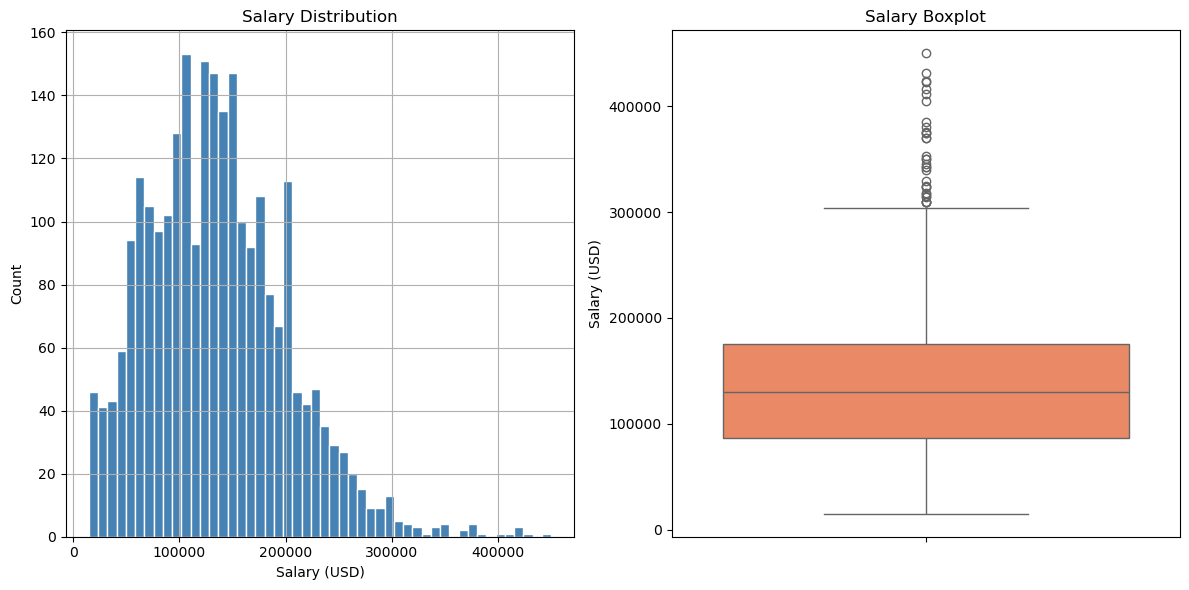

Mean:   $135,653
Median: $130,000
Min:    $15,000
Max:    $450,000


In [ ]:
plt.subplot(1, 2, 1)
df_clean['salary_in_usd'].hist(bins=50, 
                                color='steelblue', 
                                edgecolor='white')
plt.title('Salary Distribution')
plt.xlabel('Salary (USD)')
plt.ylabel('Count')

# Right — boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['salary_in_usd'], color='coral')
plt.title('Salary Boxplot')
plt.ylabel('Salary (USD)')

plt.tight_layout()
plt.show()

print(f"Mean:   ${df_clean['salary_in_usd'].mean():,.0f}")
print(f"Median: ${df_clean['salary_in_usd'].median():,.0f}")
print(f"Min:    ${df_clean['salary_in_usd'].min():,.0f}")
print(f"Max:    ${df_clean['salary_in_usd'].max():,.0f}")

C:\Users\caryl\AppData\Local\Temp\ipykernel_17588\1121430462.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean,


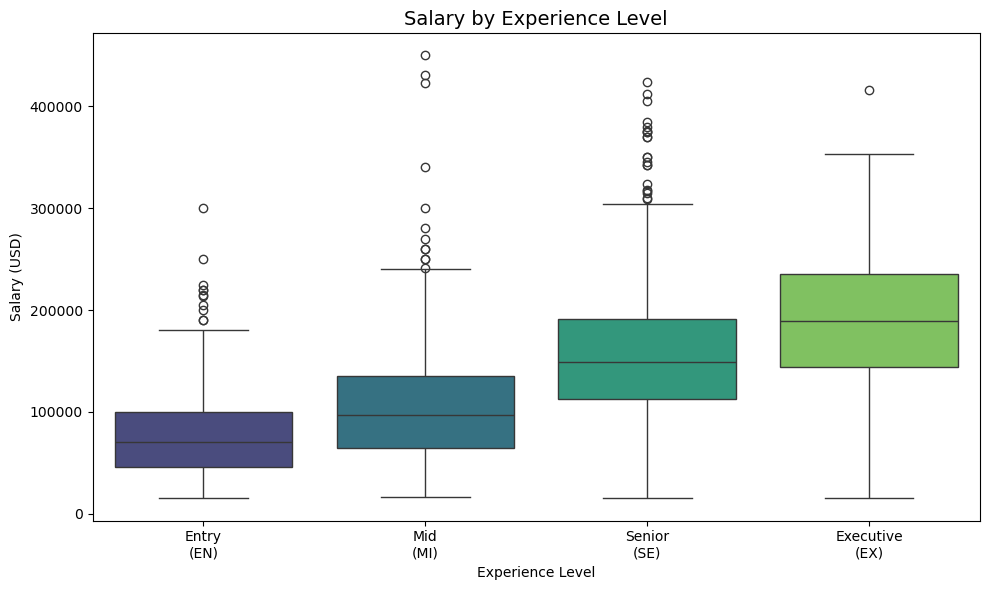

experience_level
EN     $79,919
MI    $103,970
SE    $154,175
EX    $191,078
Name: salary_in_usd, dtype: object


In [ ]:
plt.figure(figsize=(10, 6))

# Order ng experience level
order = ['EN', 'MI', 'SE', 'EX']

sns.boxplot(data=df_clean, 
            x='experience_level',
            y='salary_in_usd',
            order=order,
            palette='viridis')

plt.title('Salary by Experience Level', fontsize=14)
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.xticks(ticks=[0,1,2,3], 
           labels=['Entry\n(EN)', 'Mid\n(MI)', 
                   'Senior\n(SE)', 'Executive\n(EX)'])
plt.tight_layout()
plt.show()

# Average per level
print(df_clean.groupby('experience_level')['salary_in_usd']
              .mean()
              .reindex(order)
              .apply(lambda x: f"${x:,.0f}"))

C:\Users\caryl\AppData\Local\Temp\ipykernel_17588\2634639266.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_titles.values,


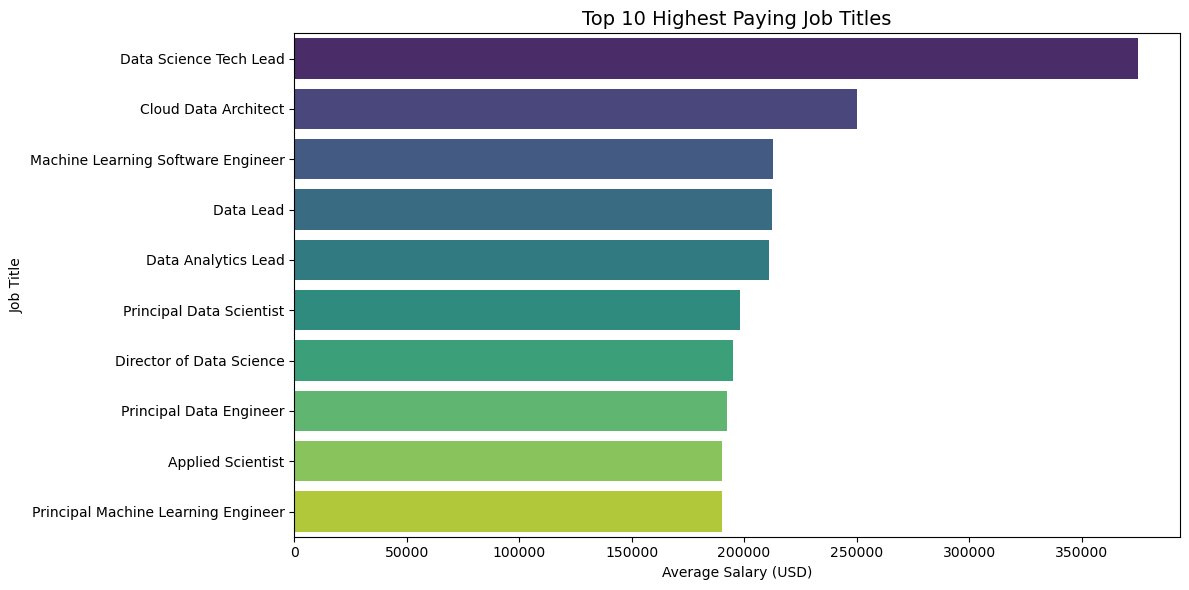

job_title
Data Science Tech Lead                 $375,000
Cloud Data Architect                   $250,000
Machine Learning Software Engineer     $212,689
Data Lead                              $212,500
Data Analytics Lead                    $211,254
Principal Data Scientist               $198,171
Director of Data Science               $195,141
Principal Data Engineer                $192,500
Applied Scientist                      $190,343
Principal Machine Learning Engineer    $190,000
Name: salary_in_usd, dtype: object


In [ ]:
plt.figure(figsize=(12, 6))

top_titles = df_clean.groupby('job_title')['salary_in_usd']\
                     .mean()\
                     .sort_values(ascending=False)\
                     .head(10)

sns.barplot(x=top_titles.values,
            y=top_titles.index,
            palette='viridis')

plt.title('Top 10 Highest Paying Job Titles', fontsize=14)
plt.xlabel('Average Salary (USD)')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

print(top_titles.apply(lambda x: f"${x:,.0f}"))

C:\Users\caryl\AppData\Local\Temp\ipykernel_17588\2279759457.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values,


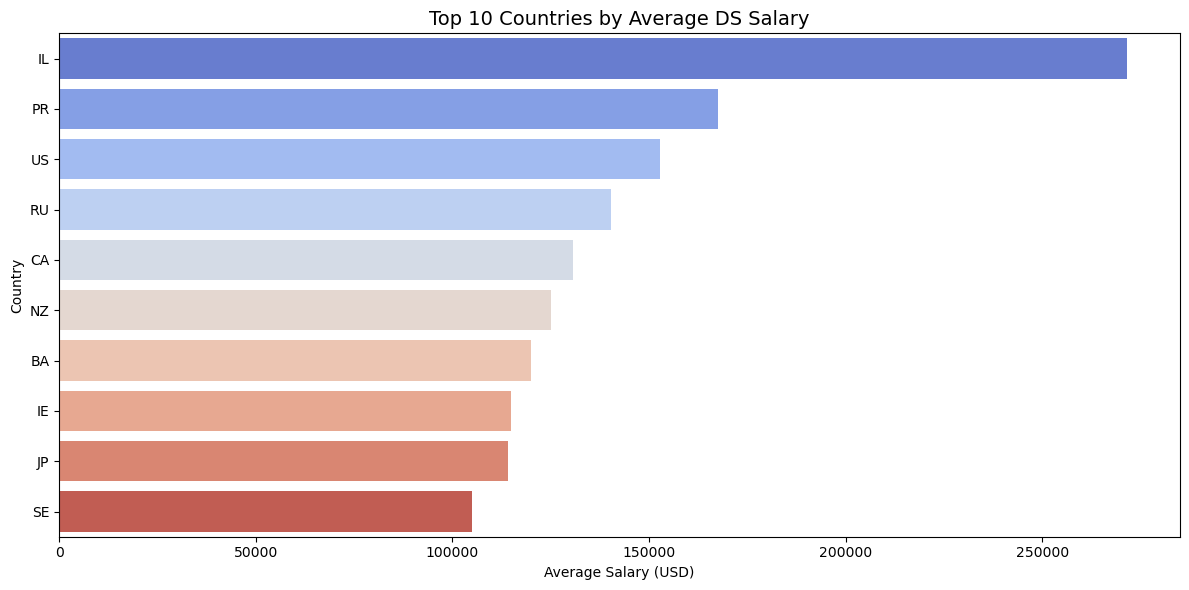

company_location
IL    $271,446
PR    $167,500
US    $152,670
RU    $140,333
CA    $130,573
NZ    $125,000
BA    $120,000
IE    $114,943
JP    $114,127
SE    $105,000
Name: salary_in_usd, dtype: object


In [ ]:
plt.figure(figsize=(12, 6))

top_countries = df_clean.groupby('company_location')['salary_in_usd']\
                        .mean()\
                        .sort_values(ascending=False)\
                        .head(10)

sns.barplot(x=top_countries.values,
            y=top_countries.index,
            palette='coolwarm')

plt.title('Top 10 Countries by Average DS Salary', fontsize=14)
plt.xlabel('Average Salary (USD)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

print(top_countries.apply(lambda x: f"${x:,.0f}"))

In [ ]:
print(df_clean['company_location'].value_counts().head(10))

company_location
US    1925
GB     155
CA      83
DE      55
ES      43
IN      41
FR      33
PT      14
AU      14
NL      13
Name: count, dtype: int64


In [ ]:
# to check how many entry per country

countries_check = ['IL', 'PR', 'RU', 'US', 'CA', 'GB']

for country in countries_check:
    count = len(df_clean[df_clean['company_location'] == country])
    avg = df_clean[df_clean['company_location'] == country]['salary_in_usd'].mean()
    print(f"{country}: {count} entries — avg ${avg:,.0f}")

IL: 2 entries — avg $271,446
PR: 4 entries — avg $167,500
RU: 3 entries — avg $140,333
US: 1925 entries — avg $152,670
CA: 83 entries — avg $130,573
GB: 155 entries — avg $87,685


C:\Users\caryl\AppData\Local\Temp\ipykernel_17588\3468602685.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_salary',


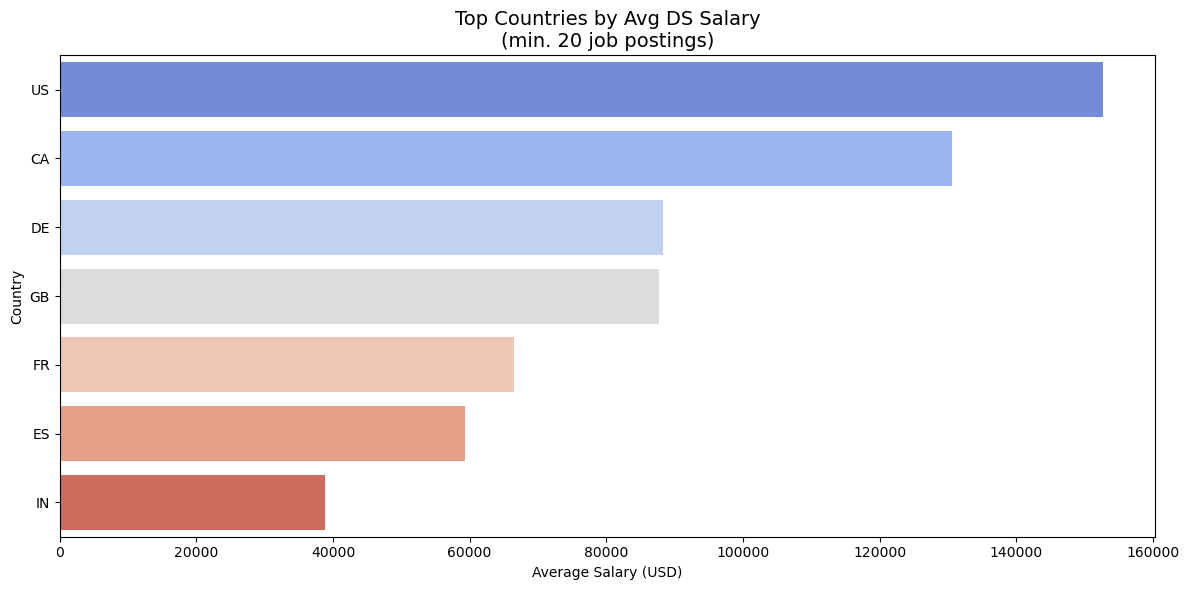

company_location    avg_salary  count
              US 152669.763117   1925
              CA 130572.759036     83
              DE  88244.345455     55
              GB  87685.000000    155
              FR  66551.030303     33
              ES  59337.465116     43
              IN  38789.439024     41


In [ ]:
plt.figure(figsize=(12, 6))


country_stats = df_clean.groupby('company_location').agg(
    avg_salary=('salary_in_usd', 'mean'),
    count=('salary_in_usd', 'count')
).reset_index()

reliable = country_stats[country_stats['count'] >= 20]\
           .sort_values('avg_salary', ascending=False)\
           .head(10)

sns.barplot(x='avg_salary',
            y='company_location',
            data=reliable,
            palette='coolwarm')

plt.title('Top Countries by Avg DS Salary\n(min. 20 job postings)', 
          fontsize=14)
plt.xlabel('Average Salary (USD)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

print(reliable[['company_location', 
                'avg_salary', 
                'count']].to_string(index=False))

In [ ]:
# to check how many work year value coutns
print(df_clean['work_year'].value_counts().sort_index())

work_year
2020      69
2021     214
2022    1105
2023    1150
Name: count, dtype: int64


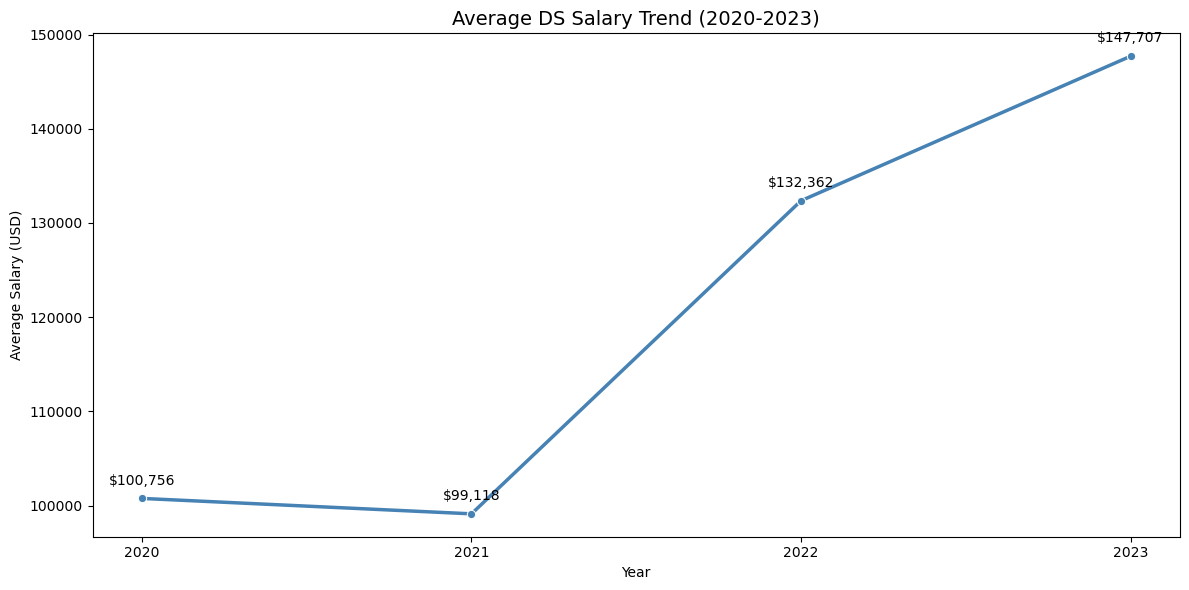

   work_year  salary_in_usd
0       2020  100755.985507
1       2021   99118.121495
2       2022  132362.414480
3       2023  147706.688696


In [ ]:
plt.figure(figsize=(12, 6))

yearly = df_clean.groupby('work_year')['salary_in_usd']\
                 .mean()\
                 .reset_index()

sns.lineplot(data=yearly,
             x='work_year',
             y='salary_in_usd',
             marker='o',
             linewidth=2.5,
             color='steelblue')

# Add value labels sa bawat point
for _, row in yearly.iterrows():
    plt.annotate(f"${row['salary_in_usd']:,.0f}",
                 (row['work_year'], row['salary_in_usd']),
                 textcoords="offset points",
                 xytext=(0, 10),
                 ha='center',
                 fontsize=10)

plt.title('Average DS Salary Trend (2020-2023)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Salary (USD)')
plt.xticks([2020, 2021, 2022, 2023])
plt.tight_layout()
plt.show()

print(yearly)

C:\Users\caryl\AppData\Local\Temp\ipykernel_17588\382227298.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=remote_salary,


Text(0.5, 1.0, 'Average')

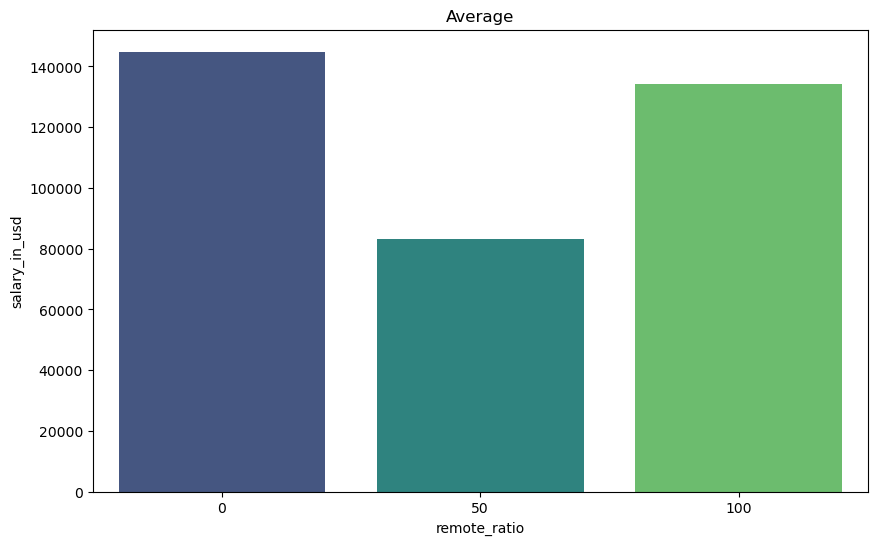

In [ ]:
plt.figure(figsize=(10, 6))

remote_salary = df_clean.groupby('remote_ratio')['salary_in_usd']\
                        .mean()\
                        .reset_index()

sns.barplot(data=remote_salary,
            x='remote_ratio',
            y='salary_in_usd',
            palette='viridis')

plt.title('Average')

C:\Users\caryl\AppData\Local\Temp\ipykernel_17588\725015706.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=size_salary,


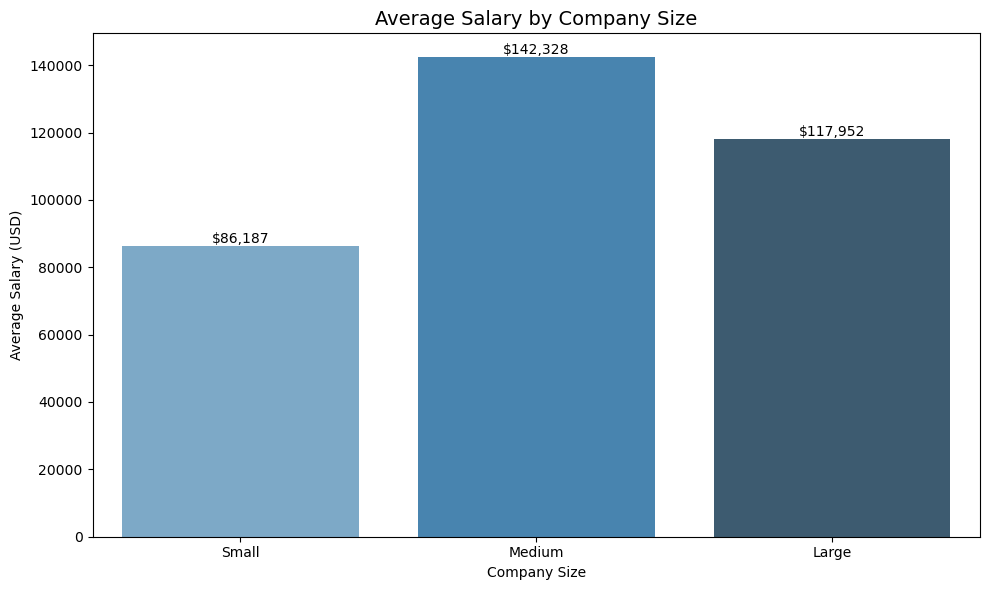

  company_size  salary_in_usd
0            S   86186.636364
1            M  142327.841191
2            L  117952.340153


In [ ]:
plt.figure(figsize=(10, 6))

size_order = ['S', 'M', 'L']
size_labels = ['Small', 'Medium', 'Large']

size_salary = df_clean.groupby('company_size')['salary_in_usd']\
                      .mean()\
                      .reindex(size_order)\
                      .reset_index()

sns.barplot(data=size_salary,
            x='company_size',
            y='salary_in_usd',
            order=size_order,
            palette='Blues_d')

plt.title('Average Salary by Company Size', fontsize=14)
plt.xlabel('Company Size')
plt.ylabel('Average Salary (USD)')
plt.xticks(ticks=[0,1,2], labels=size_labels)

# Add value labels
for i, row in size_salary.iterrows():
    plt.text(i, row['salary_in_usd'] + 1000,
             f"${row['salary_in_usd']:,.0f}",
             ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(size_salary)

1. Median DS salary    = $130,000
2. Experience matters  = EN $79K → EX $191K
3. Best title          = DS Tech Lead ($375K)
4. Best country        = US ($152K)
5. Salary growing      = +46% from 2020-2023
6. Remote vs Onsite    = Onsite slightly higher
7. Best company size   = Medium ($142K)